In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder,RobustScaler,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('loan_data.csv')

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
num = df.select_dtypes(include='number').columns


<Axes: >

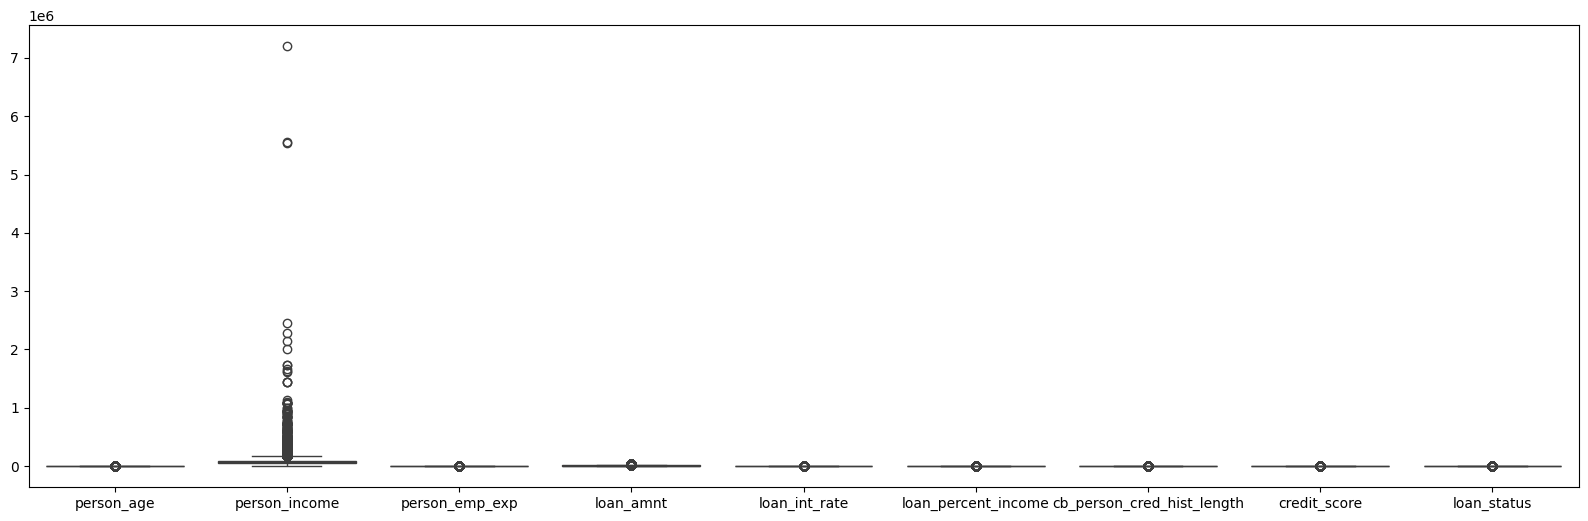

In [5]:
plt.figure(figsize=(20,6))
sns.boxplot(df[num])

In [6]:
df.shape

(45000, 14)

In [7]:
x = df.drop(columns='loan_status')
y = df['loan_status']

In [8]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

In [9]:
cat_cols = x.select_dtypes(include='object').columns
num_cols = x.select_dtypes(include='number').drop(columns='person_income').columns

C:\Users\dhanu\AppData\Local\Temp\ipykernel_28468\4012906165.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include='object').columns


In [10]:
preprocessing = ColumnTransformer(
    transformers=[
        ('encoder',OneHotEncoder(),cat_cols),
        ('scaling',RobustScaler(),['person_income']),
        ('scaling1',StandardScaler(),num_cols)
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessing',preprocessing),
        ('model',SVC())
    ]
)

In [11]:
ytrain.value_counts()

loan_status
0    28010
1     7990
Name: count, dtype: int64

In [ ]:
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid={
        'model__C':[0.001,0.01,0.1,1,10,100],
        'model__kernel':['rbf','linear','sigmoid','poly'],
        'model__degree':[2,3,5] 
    },
    verbose=1,
    n_jobs=-1 
)
grid_search.fit(xtrain,ytrain)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
